In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ДЗ 1 ПУНКТ

Изображение готово
Размер: (400, 600)


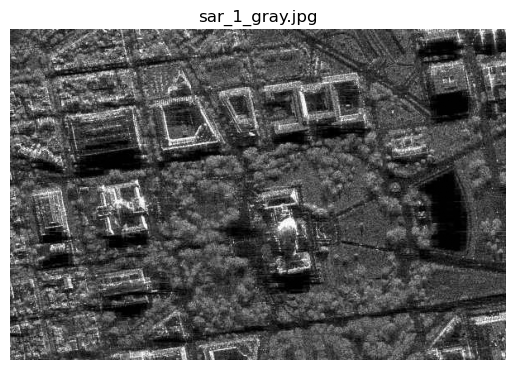

In [1]:
import cv2
import matplotlib.pyplot as plt

image_gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

if image_gray is None:
    print('Изображение не нашлось')
else:
    print('Изображение готово')
    print('Размер:', image_gray.shape)

    # Отображение изображения
    plt.imshow(image_gray, cmap='gray')
    plt.title('sar_1_gray.jpg')
    plt.axis('off')
    plt.show()

# ДЗ 2 ПУНКТ

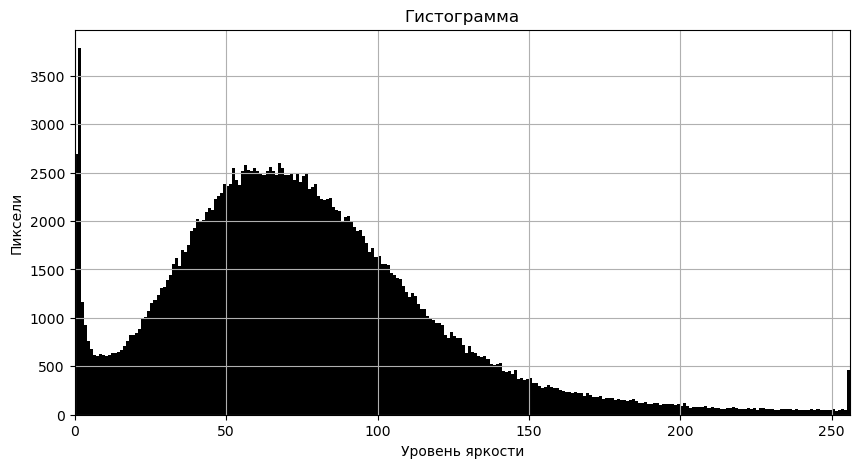

In [2]:
plt.figure(figsize=(10, 5))

plt.hist(image_gray.ravel(), bins=256, range=(0, 256), color='black')

plt.title('Гистограмма')
plt.xlabel('Уровень яркости')
plt.ylabel('Пиксели')
plt.xlim([0, 256])
plt.grid()

plt.show()

# ДЗ 3 ПУНКТ

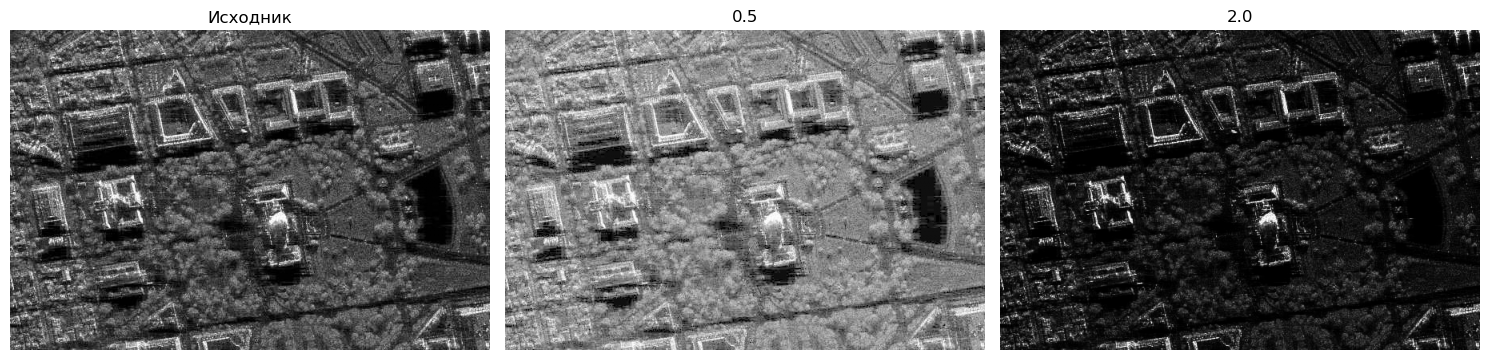

In [3]:
import numpy as np

def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    return np.uint8(corrected * 255)

image_gamma_less_1 = gamma_correction(image_gray, 0.5)

image_gamma_greater_1 = gamma_correction(image_gray, 2.0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходник')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_gamma_less_1, cmap='gray')
plt.title('0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_gamma_greater_1, cmap='gray')
plt.title('2.0')
plt.axis('off')

plt.tight_layout()
plt.show()

# ДЗ 4 ПУНКТ

In [4]:
from skimage.metrics import mean_squared_error, structural_similarity

mse_less_1 = mean_squared_error(image_gray, image_gamma_less_1)
ssim_less_1 = structural_similarity(
    image_gray,
    image_gamma_less_1,
    data_range=255
)

mse_greater_1 = mean_squared_error(image_gray, image_gamma_greater_1)
ssim_greater_1 = structural_similarity(
    image_gray,
    image_gamma_greater_1,
    data_range=255
)

print('0.5')
print('MSE:', mse_less_1)
print('SSIM:', ssim_less_1)

print('\n 2.0')
print('MSE:', mse_greater_1)
print('SSIM:', ssim_greater_1)

0.5
MSE: 3250.429145833333
SSIM: 0.7875008686792752

 2.0
MSE: 2383.7636375
SSIM: 0.5270459922820343


# ДЗ 5 ПУНКТ

Исходик:
Среднее: 74.94157083333333
Стандартное отклонение: 43.658465466227916

eq_gray:
Среднее: 127.02563333333333
Стандартное отклонение: 74.26964841889017

Скорректированное изображение:
Среднее: 123.1181375
Стандартное отклонение: 65.3025763098039


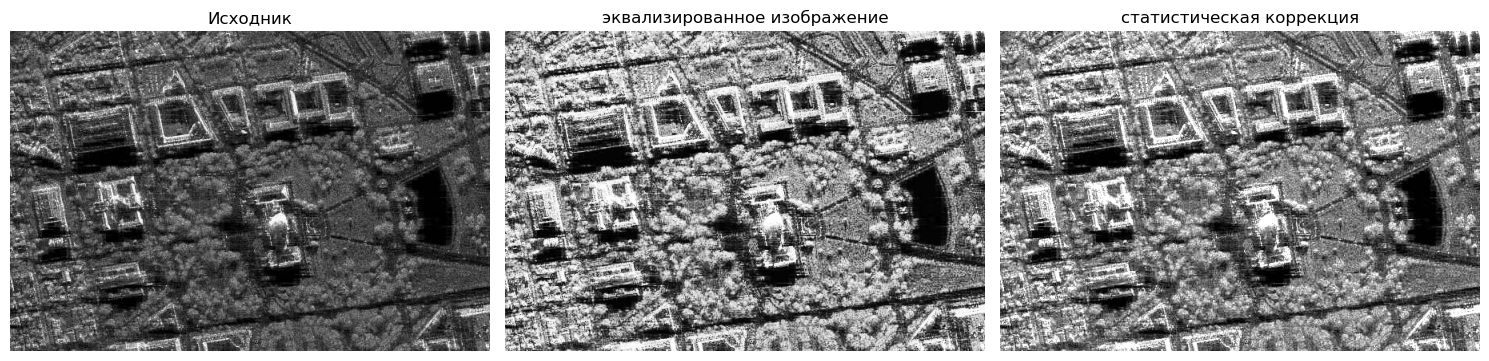

In [5]:
eq_gray = cv2.equalizeHist(image_gray)

mean_original = image_gray.mean()
std_original = image_gray.std()

mean_eq = eq_gray.mean()
std_eq = eq_gray.std()

corrected_stat = (
    (image_gray - mean_original) *
    (std_eq / std_original) +
    mean_eq
)

corrected_stat = np.clip(corrected_stat, 0, 255).astype(np.uint8)

print('Исходик:')
print('Среднее:', mean_original)
print('Стандартное отклонение:', std_original)

print('\neq_gray:')
print('Среднее:', mean_eq)
print('Стандартное отклонение:', std_eq)

print('\nСкорректированное изображение:')
print('Среднее:', corrected_stat.mean())
print('Стандартное отклонение:', corrected_stat.std())

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходник')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('эквализированное изображение')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(corrected_stat, cmap='gray')
plt.title('статистическая коррекция')
plt.axis('off')

plt.tight_layout()
plt.show()

# ДЗ 6 ПУНКТ

Порог: 50
Белые пиксели: 169178
Чёрные пиксели: 70822

Порог: 100
Белые пиксели: 55653
Чёрные пиксели: 184347

Порог: 150
Белые пиксели: 13083
Чёрные пиксели: 226917

Порог: 200
Белые пиксели: 3830
Чёрные пиксели: 236170



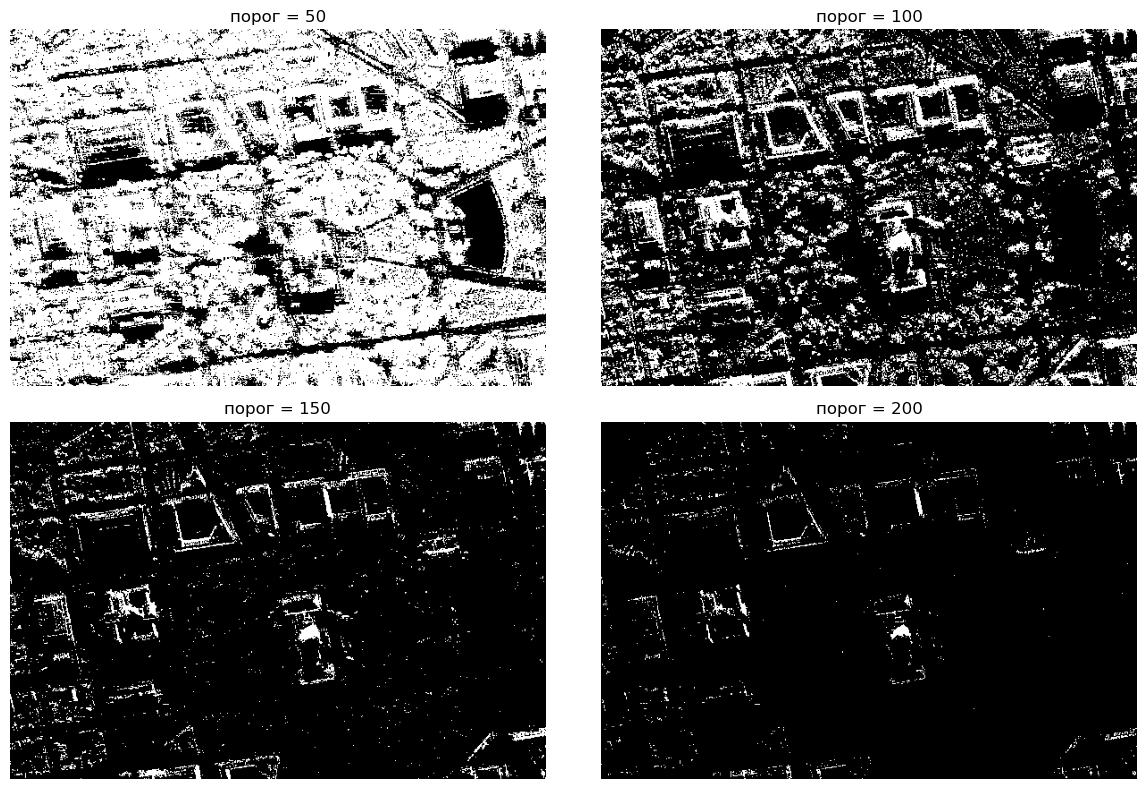

In [6]:

thresholds = [50, 100, 150, 200]

results = []

for threshold in thresholds:
    _, result = cv2.threshold(
        image_gray,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    results.append(result)

    white_pixels = np.sum(result == 255)
    black_pixels = np.sum(result == 0)

    print(f'Порог: {threshold}')
    print(f'Белые пиксели: {white_pixels}')
    print(f'Чёрные пиксели: {black_pixels}')
    print()


plt.figure(figsize=(12, 8))

for i in range(len(thresholds)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(results[i], cmap='gray')
    plt.title(f'порог = {thresholds[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Конвертация цветовых моделей

In [7]:
image_template[0,0]

<class 'NameError'>: name 'image_template' is not defined

In [ ]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [ ]:
image_gray[0,0]

In [ ]:
image_gray.shape

In [ ]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [ ]:
image_hsv.shape

In [ ]:
image_hsv[0,0]

In [ ]:
image[0,0]

In [ ]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [ ]:
image_lab[0,0]

# Пороговая фильтрация

In [ ]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

In [ ]:
plt.imshow(thresh1, cmap='gray')

In [ ]:
thresh1[thresh1==100].sum()

# Построение гистограммы

In [ ]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

In [ ]:
plt.plot(b_hist)

In [ ]:
b_hist_cum = b_hist.cumsum()

In [ ]:
plt.plot(b_hist_cum)

In [ ]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

In [ ]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [ ]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

In [ ]:
plt.imshow(diff)

In [ ]:
mse = mean_squared_error(image_gray, image_gray)
mse

# Статистические характеристики изображений

In [ ]:
mean = image_gray.mean()

In [ ]:
std = image_gray.std()

In [ ]:
print(mean,std)

In [ ]:
eq_gray = cv2.equalizeHist(image_gray)

In [ ]:
plt.imshow(eq_gray, cmap="gray")


In [ ]:
plt.imshow(image_gray, cmap="gray")

In [ ]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат
